## Imports and preparations

In [ ]:
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import json
from tqdm import tqdm
from pathlib import Path
import pickle
from src.similarity_matrix import (
    create_sim_m_heatmap,
)
from src.find_overlapping_books import (
    book_id_to_path,
    parish_check_overlaps_by_year,
    check_churchbook_overlaps_by_year,
)
from src.find_overlapping_books import (
    books_sim_m,
    check_book_overlap,
)
import matplotlib.pyplot as plt

### Input paths:

In [2]:
record_parishes_csv = "data/csv/Moving_record_parishes_with_formats_v2.csv"
recorod_formats_csv = "data/csv/Moving_record_formats_v2.csv"
migration_data_dir = "data/migration-data-csv-release-v1"
overlapping_books_sim_m_dir = "sim_matrices/overlapping_books"

### Output paths:

In [3]:
possible_overlaps_json = "outputs/json/possible_overlapping_ids.json"
book_ids_json = "outputs/json/book_ids.json"
overlap_metadata_json = "outputs/json/book_overlaps.json"
matrices_with_overlap_json = "outputs/json/matrices_with_overlap.json"
matrices_with_overlap_type_json = "outputs/json/matrices_with_overlap_type.json"
evaluated_overlap_sim_matrices_json = "outputs/json/evaluated_overlap_sim_matrices.json"

In [4]:
record_parishes_rows = []
with open(record_parishes_csv) as fp:
    reader = csv.reader(fp)
    for row in reader:
        record_parishes_rows.append(row)
record_parishes_columns = record_parishes_rows.pop(0)
record_parishes_rows = record_parishes_rows[:-1]

record_formats_rows = []
with open(recorod_formats_csv) as fp:
    reader = csv.reader(fp)
    for row in reader:
        record_formats_rows.append(row)
record_formats_columns = record_formats_rows.pop(0)

In [5]:
record_parishes_end_col = record_parishes_columns.index("Example")
record_parishes_columns = record_parishes_columns[:record_parishes_end_col]
record_parishes_rows = [
    r[:record_parishes_end_col] for r in record_parishes_rows
]

In [6]:
record_formats_col_def = record_formats_columns.index("sarakkeet")
record_formats_columns = record_formats_columns[: record_formats_col_def + 1]

for i in range(len(record_formats_rows)):
    r = record_formats_rows[i]
    r_cols = [c for c in r[record_formats_col_def:] if len(c) > 0]
    r = r[:record_formats_col_def]
    r.append(r_cols)
    record_formats_rows[i] = r

In [7]:
record_parishes_df = pd.DataFrame(
    record_parishes_rows, columns=record_parishes_columns
)
record_formats_df = pd.DataFrame(
    record_formats_rows, columns=record_formats_columns
)

record_parishes_df = record_parishes_df.replace("", np.nan)
record_formats_df = record_formats_df.replace("", np.nan)

## Modifying the metadata

In [8]:
parish_ids = record_parishes_df["parish_id"].unique().tolist()

In [9]:
record_parishes_df = record_parishes_df.drop(
    ["doc", "additional", "added_year", "kartta", "Notes"], axis="columns"
)
record_parishes_df["Luokittelu"] = record_parishes_df["Luokittelu"].str.lower()
record_parishes_df["Start_year"] = record_parishes_df["Start_year"].astype(int)
record_parishes_df["End_year"] = record_parishes_df["End_year"].astype(int)

In [10]:
record_parishes_df["book_id"] = (
    record_parishes_df["url"].str.split("bid=").str[1]
)
book_id_to_book = (
    record_parishes_df[
        ["parish_normalized", "Start_year", "End_year", "source", "book_id"]
    ]
    .set_index("book_id")
    .to_dict("index")
)

with open(book_ids_json, "w") as fp:
    json.dump(book_id_to_book, fp)

In [11]:
in_out = []
for i in record_parishes_df.T:
    classification = record_parishes_df.loc[i]["Luokittelu"]
    record_in_out = record_formats_df[
        record_formats_df["print type"] == classification
    ]["in/out"].to_list()

    in_out_dict = {"in": False, "out": False, "misc": False}

    if record_in_out:
        if "in" in record_in_out:
            in_out_dict["in"] = True
        if "out" in record_in_out:
            in_out_dict["out"] = True
        for in_out_type in record_in_out:
            if in_out_type not in ["in", "out", "misc"]:
                in_out_dict["misc"] = True
                break
    else:
        if (
            " in" in classification
            or "/in" in classification
            or "in/" in classification
        ):
            in_out_dict["in"] = True
        if (
            " out" in classification
            or "/out" in classification
            or "out/" in classification
        ):
            in_out_dict["out"] = True
        if "misc" in classification:
            in_out_dict["misc"] = True

    in_out.append(in_out_dict)

record_parishes_df["in/out"] = in_out

## Recognizing and marking duplicate/overlapping books

**Overlap** = Two books share some events

**Duplicate** = Two books share most events

**Candidate** = Possible overlap or duplicate

### Recognize possible candidates

In [12]:
overlapping_books = {
    "full": [],
    "partial_center": [],
    "partial_left_or_right": [],
    "no_overlap": []
}

for p_id in parish_ids:
    parish_books = record_parishes_df[
        record_parishes_df["parish_id"] == p_id
    ].to_dict("records")

    parish_overlaps = parish_check_overlaps_by_year(parish_books)

    for overlap_type in overlapping_books:
        overlapping_books[overlap_type] += parish_overlaps[overlap_type]

book_pairs = {}
for overlap_type, overlapping in overlapping_books.items():
    book_pairs[overlap_type] = [
        {
            pair[0]["book_id"]: [
                str(p)
                for p in book_id_to_path(
                    pair[0]["book_id"], book_id_to_book, migration_data_dir
                )
            ],
            pair[1]["book_id"]: [
                str(p)
                for p in book_id_to_path(
                    pair[1]["book_id"], book_id_to_book, migration_data_dir
                )
            ],
        }
        for pair in overlapping
    ]

print(*[f"{k}: {len(v)}" for k, v in overlapping_books.items()], sep="\n")

full: 232
partial_center: 165
partial_left_or_right: 763
no_overlap: 6843


In [14]:
#with open(possible_overlaps_json, "w") as fp:
with open("outputs/json/possible_overlapping_ids2.json", "w") as fp:
    json.dump(book_pairs, fp)

### Creating similarity matrix for each candidate pair

In [122]:
files_not_found = {}

for overlap_type in ["full", "partial_center", "partial_left_or_right"]:
    base_output_dir = Path(
        f"outputs/{overlapping_books_sim_m_dir}/{overlap_type}/candidates/"
    )
    files_not_found[overlap_type] = []

    for candidate_pair in tqdm(overlapping_books[overlap_type]):
        base_folder = Path(migration_data_dir)/candidate_pair[0]["parish_normalized"]
        sim_m, slices_a, slices_b, page_lens_a, page_lens_b = books_sim_m(
            candidate_pair, base_folder, use_whole_pages=True
        )
        if sim_m.shape <= (1, 0):
            files_not_found[overlap_type].append(candidate_pair)
            continue

        file_name = (
            candidate_pair[0]["book_id"] + "_" + candidate_pair[1]["book_id"]
        )
        candidate = {
            "sim_m": sim_m,
            "slices_a": slices_a,
            "slices_b": slices_b,
            "page_lens_a": page_lens_a,
            "page_lens_b": page_lens_b,
            "book_id_a": candidate_pair[0]["book_id"],
            "book_id_b": candidate_pair[1]["book_id"],
        }
        save_path = base_output_dir / file_name
        with open(save_path, "wb") as fp:
            pickle.dump(candidate, fp)

100%|██████████| 763/763 [02:43<00:00,  4.67it/s]


In [123]:
def check_book_overlap(
    sim_m, threshold, n_overlaps_required, block_size=1, step=1
):
    if (
        len(overlaps := np.column_stack(np.where(sim_m >= threshold)))
        >= n_overlaps_required
    ):
        return True, overlaps
    else:
        return False, []


overlaps = {}
no_overlaps = {}

for overlap_type in ["full", "partial_left_or_right", "partial_center"]:
    candidates_dir = Path(
        f"outputs/{overlapping_books_sim_m_dir}/{overlap_type}/candidates/"
    )
    sim_matrices = [str(p) for p in candidates_dir.glob("*") if p.is_file()]
    overlaps[overlap_type] = []
    no_overlaps[overlap_type] = []

    for candidate in tqdm(sim_matrices):
        with open(candidate, "rb") as fp:
            c = pickle.load(fp)

        has_overlap, books_overlaps = check_book_overlap(c["sim_m"], 0.5, 1)

        file_name = c["book_id_a"] + "_" + c["book_id_b"] + ".npy"
        if has_overlap:
            overlaps[overlap_type].append(
                (c, c["book_id_a"], c["book_id_b"], books_overlaps)
            )
        else:
            no_overlaps[overlap_type].append(
                (c, c["book_id_a"], c["book_id_b"])
            )

print("Overlaps:", sum([len(x) for x in overlaps.values()]))
print("No overlaps:", sum([len(x) for x in no_overlaps.values()]))

100%|██████████| 156/156 [00:00<00:00, 1184.42it/s]

Overlaps: 825
No overlaps: 317


In [ ]:
"""
%matplotlib inline
from time import sleep


start_from_idx = 0
last_idx = start_from_idx
checked_overlaps = []

for overlap_type in overlaps:
    for i, overlap in enumerate(overlaps[overlap_type], start=start_from_idx):
        o_sim_m = overlap[0]["sim_m"]
        o_overlaps = overlap[3]
        plt.ion()
        ax = create_sim_m_heatmap(
            o_sim_m,
            ylabel="-".join(
                str(v) for v in book_id_to_book[overlap[1]].values()
            ),
            xlabel="-".join(
                str(v) for v in book_id_to_book[overlap[2]].values()
            ),
            vmin=0,
            vmax=1.0,
            zeros_together=True
        )
        display(plt.gcf(), clear=True)
        print("Y:", overlap[1], "X:", overlap[2])
        print("overlap_type", overlap_type, "idx:", i)
        ax.figure.canvas.flush_events()

        evaluation = input("overlap?")
        if evaluation != "n":
            metadata = {
                "book_id_a": overlap[1],
                "book_id_b": overlap[2],
                #"a_overlap_ranges": input("overlap ranges y"),
                #"b_overlap_ranges": input("overlap ranges x"),
            }

            checked_overlaps.append(metadata)
        last_idx = i
display("", clear=True)
"""

In [ ]:
"""
with open("checked_overlap_matrices.json", "w") as fp:
    json.dump(checked_overlaps, fp)
with open("evaluated_overlap_sim_matrices.json", "w") as fp:
    json.dump(checked_overlaps, fp)
"""

## Looking at results and creating a metadata file

In [18]:
book_pairs_list = []
for overlap_type in book_pairs.keys():
    book_pairs_list += [
        list(pair.keys()) + [overlap_type] for pair in book_pairs[overlap_type]
    ]
book_pairs_df = pd.DataFrame(
    book_pairs_list, columns=["book_id_a", "book_id_b", "years_overlap"]
)

book_pairs_df["book_id_a"] = book_pairs_df["book_id_a"].astype(str)
book_pairs_df["book_id_b"] = book_pairs_df["book_id_b"].astype(str)
book_pairs_df["years_overlap"] = book_pairs_df["years_overlap"].astype(str)

In [19]:
matrices_with_overlap_df = pd.read_json(
    matrices_with_overlap_json, orient="records"
)
matrices_with_overlap_df["book_id_a"] = matrices_with_overlap_df["book_id_a"].astype(str)
matrices_with_overlap_df["book_id_b"] = matrices_with_overlap_df["book_id_b"].astype(str)

In [20]:
matrices_with_overlap_df = matrices_with_overlap_df.merge(
    book_pairs_df, on=["book_id_a", "book_id_b"], how="left"
)
matrices_with_overlap_df

,book_id_a,book_id_b,years_overlap
0,38072,13113,full
1,38732,11730,full
2,33356,12810,full
3,22975,10709,full
4,41456,14958,full
...,...,...,...
727,45183,1789,partial_center
728,24794,6399,partial_center
729,37863,12519,partial_center
730,41911,20252,partial_center


In [21]:
matrices_with_overlap_records = []
for i in matrices_with_overlap_df.T:
    matrices_with_overlap_records.append(
        matrices_with_overlap_df.loc[i].to_dict()
    )


In [22]:
#with open(matrices_with_overlap_type_json, "w") as fp:
    #json.dump(matrices_with_overlap_records, fp)

In [23]:
checked_overlaps_df = pd.read_json(
    evaluated_overlap_sim_matrices_json, orient="records"
)
book_pairs_list = []
for overlap_type in book_pairs.keys():
    book_pairs_list += [
        list(pair.keys()) + [overlap_type] for pair in book_pairs[overlap_type]
    ]
book_pairs_df = pd.DataFrame(
    book_pairs_list, columns=["book_id_a", "book_id_b", "years_overlap"]
)

In [24]:
checked_overlaps_df["book_id_a"] = checked_overlaps_df["book_id_a"].astype(str)
checked_overlaps_df["book_id_b"] = checked_overlaps_df["book_id_b"].astype(str)

book_pairs_df["book_id_a"] = book_pairs_df["book_id_a"].astype(str)
book_pairs_df["book_id_b"] = book_pairs_df["book_id_b"].astype(str)
book_pairs_df["years_overlap"] = book_pairs_df["years_overlap"].astype(str)

In [25]:
checked_overlaps_df = checked_overlaps_df.merge(
    book_pairs_df, on=["book_id_a", "book_id_b"], how="left"
)

In [26]:
checked_overlaps_df["a_overlap_type"].unique()

<ArrowStringArray>
['lr', 'f', 'l', 'r', 'c', 'fs', 'rs', 'lc', 'u', 'cr', 'ls', 'cs', 'rc']
Length: 13, dtype: str

In [27]:
overlap_char_to_full_text = {
    "l": "left",
    "c": "center",
    "r": "right",
    "f": "full",
    "s": "split",
    "u": "unsure",
}
sim_m_evaluation_to_full_text = {
    "y": "overlap",
    "n": "no_overlap",
    "u": "unsure",
}


def overlap_chars_to_list(overlap: str, overlap_char_to_full_text):
    output = []
    for i in range(len(overlap)):
        txt = overlap_char_to_full_text.get(overlap[i], overlap[i])

        if output and txt == "split":
            output[-1] += "_" + txt
        else:
            output.append(txt)

    return output


checked_overlaps_df["a_overlap_type"] = checked_overlaps_df[
    "a_overlap_type"
].apply(
    lambda overlap: overlap_chars_to_list(overlap, overlap_char_to_full_text)
)
checked_overlaps_df["b_overlap_type"] = checked_overlaps_df[
    "b_overlap_type"
].apply(
    lambda overlap: overlap_chars_to_list(overlap, overlap_char_to_full_text)
)
checked_overlaps_df["evaluation"] = checked_overlaps_df["evaluation"].apply(
    lambda evaluation: sim_m_evaluation_to_full_text.get(
        evaluation, evaluation
    )
)

In [28]:
checked_overlaps_df

,book_id_a,book_id_b,a_overlap_type,b_overlap_type,evaluation,years_overlap
0,38072,13113,"[left, right]","[left, right]",overlap,full
1,38732,11730,[full],[full],overlap,full
2,33356,12810,[full],[full],overlap,full
3,22975,10709,[full],[full],overlap,full
4,41456,14958,[full],[full],overlap,full
...,...,...,...,...,...,...
721,45183,1789,[center],"[left, right]",overlap,partial_center
722,24794,6399,[left],[full],overlap,partial_center
723,37863,12519,[right],[full],overlap,partial_center
724,41911,20252,[center],[full],overlap,partial_center


In [29]:
checked_overlaps_df[
    checked_overlaps_df["a_overlap_type"].str.contains("unsure", regex=False)
    | checked_overlaps_df["b_overlap_type"].str.contains("unsure", regex=False)
    | checked_overlaps_df["evaluation"].str.contains("unsure", regex=False)
]

,book_id_a,book_id_b,a_overlap_type,b_overlap_type,evaluation,years_overlap
101,26339,26341,"[left, right]",[right],unsure,full
201,34579,10030,[unsure],"[left, right]",overlap,partial_left_or_right
631,20925,13392,[right],[left],unsure,partial_left_or_right


In [30]:
pair = [
    pair
    for pair in overlapping_books["partial_left_or_right"]
    if pair[0]["book_id"] == "34579" and pair[1]["book_id"] == "10030"
][0]
base_folder = Path(
    migration_data_dir + pair[0]["parish_normalized"]
)
sim_m, slices_a, slices_b, page_lens_a, page_lens_b = books_sim_m(
    pair, base_folder, block_size=3, step=1, use_whole_pages=True
)

thresholded = np.column_stack(np.where(sim_m > 0.5))
for indexes in thresholded:
    print(slices_a[indexes[0]], slices_b[indexes[1]])

In [31]:
checked_overlaps_df.to_dict(orient="records")

[{'book_id_a': '38072',
  'book_id_b': '13113',
  'a_overlap_type': ['left', 'right'],
  'b_overlap_type': ['left', 'right'],
  'evaluation': 'overlap',
  'years_overlap': 'full'},
 {'book_id_a': '38732',
  'book_id_b': '11730',
  'a_overlap_type': ['full'],
  'b_overlap_type': ['full'],
  'evaluation': 'overlap',
  'years_overlap': 'full'},
 {'book_id_a': '33356',
  'book_id_b': '12810',
  'a_overlap_type': ['full'],
  'b_overlap_type': ['full'],
  'evaluation': 'overlap',
  'years_overlap': 'full'},
 {'book_id_a': '22975',
  'book_id_b': '10709',
  'a_overlap_type': ['full'],
  'b_overlap_type': ['full'],
  'evaluation': 'overlap',
  'years_overlap': 'full'},
 {'book_id_a': '41456',
  'book_id_b': '14958',
  'a_overlap_type': ['full'],
  'b_overlap_type': ['full'],
  'evaluation': 'overlap',
  'years_overlap': 'full'},
 {'book_id_a': '39750',
  'book_id_b': '16551',
  'a_overlap_type': ['left'],
  'b_overlap_type': ['full'],
  'evaluation': 'overlap',
  'years_overlap': 'full'},
 {'b

In [32]:
checked_overlaps_df[
    checked_overlaps_df["a_overlap_type"].isin([["full"]])
    & checked_overlaps_df["b_overlap_type"].isin([["full"]])
]

,book_id_a,book_id_b,a_overlap_type,b_overlap_type,evaluation,years_overlap
1,38732,11730,[full],[full],overlap,full
2,33356,12810,[full],[full],overlap,full
3,22975,10709,[full],[full],overlap,full
4,41456,14958,[full],[full],overlap,full
6,35964,11840,[full],[full],overlap,full
...,...,...,...,...,...,...
499,37864,14931,[full],[full],overlap,partial_left_or_right
538,33059,10666,[full],[full],overlap,partial_left_or_right
608,10665,21821,[full],[full],overlap,partial_left_or_right
619,28544,10689,[full],[full],overlap,partial_left_or_right


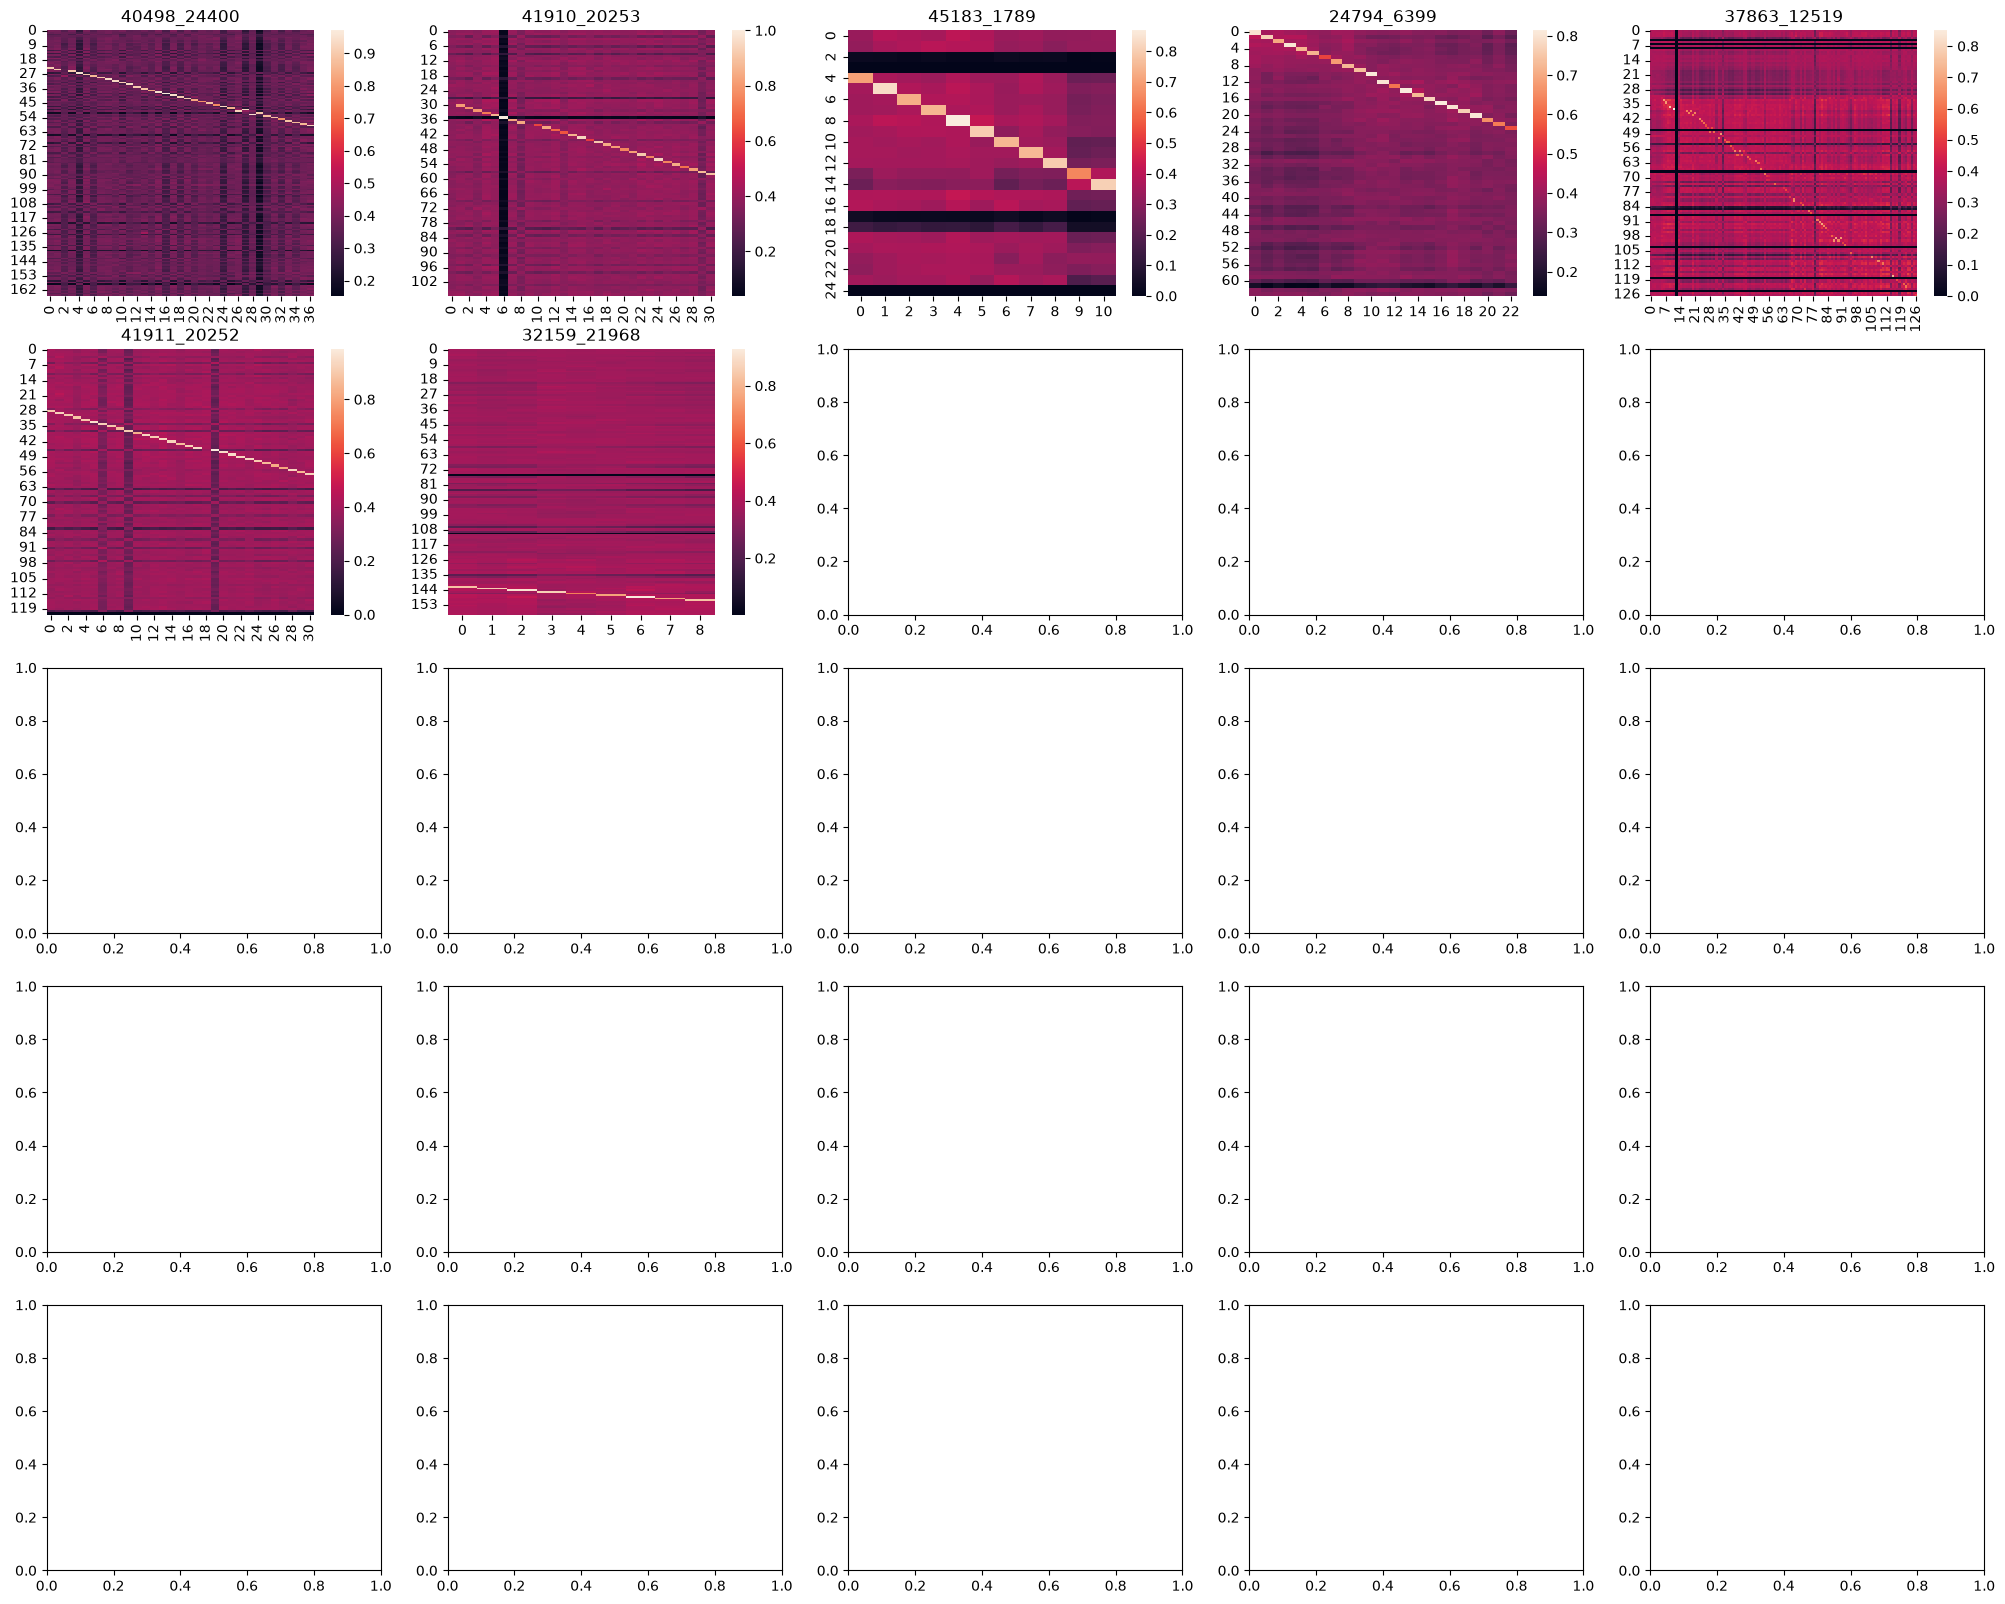

In [55]:
with open("outputs/json/matrices_with_overlap_type.json", "r") as fp:
    pairs = json.load(fp)

sim_m_paths = []
for pair in pairs:
    book_pair = str(pair["book_id_a"]) + "_" + str(pair["book_id_b"])
    overlap_type = pair["years_overlap"]
    sim_m_path = f"outputs/sim_matrices/overlapping_books/{overlap_type}/candidates/{book_pair}"
    sim_m_paths.append(sim_m_path)

fig, axs = plt.subplots(5, 5, figsize=(25, 20))

start = 725
end = start + 25
for ax, sim_m_path in zip(axs.flat, sim_m_paths[start:end]):
    try:
        with open(sim_m_path, "rb") as fp:
            overlap = pickle.load(fp)
    except FileNotFoundError as e:
        print(e)
        continue

    matrix = overlap["sim_m"]

    sns.heatmap(matrix, ax=ax)
    ax.set_title(Path(sim_m_path).stem)

## Editing final metadata file

In [411]:
overlap_metadata_df = pd.read_json("data/matrices_with_overlap_type.json", orient="records")

In [412]:
overlap_metadata_df[["a_overlap", "b_overlap"]] = pd.DataFrame(overlap_metadata_df["overlap"].tolist())
overlap_metadata_df = overlap_metadata_df.drop(["overlap"], axis="columns")

In [413]:
overlap_metadata_df.loc[
    overlap_metadata_df["b_overlap"].isna(), "b_overlap"
] = overlap_metadata_df.loc[
    overlap_metadata_df["b_overlap"].isna(), "a_overlap"
]

In [414]:
overlap_metadata_df = overlap_metadata_df.dropna()

In [415]:
overlap_metadata_df.loc[
    overlap_metadata_df["a_overlap"].str.startswith("a_"), "a_overlap"
] = overlap_metadata_df.loc[
    overlap_metadata_df["a_overlap"].str.startswith("a_"), "a_overlap"
].str.removeprefix(
    "a_"
)
overlap_metadata_df.loc[
    overlap_metadata_df["b_overlap"].str.startswith("b_"), "b_overlap"
] = overlap_metadata_df.loc[
    overlap_metadata_df["b_overlap"].str.startswith("b_"), "b_overlap"
].str.removeprefix(
    "b_"
)

In [416]:
pd.concat([overlap_metadata_df["a_overlap"], overlap_metadata_df["b_overlap"]]).value_counts()

full_discontinuous                 483
full                               268
start                              159
end                                104
end_missing_discontinuous           81
middle                              66
end_missing                         60
start_discontinuous                 50
start_missing                       43
start_missing_discontinuous         40
end_discontinuous                   29
middle_discontinuous                20
noisy                               12
full_saw_discontinuous              11
full_saw                             8
middle_missing                       6
start_missing_saw                    3
start_saw                            3
end_missing_saw                      2
middle_missing_discontinuous         2
start_duplicated                     2
full_saw_duplicated                  1
end_duplicated                       1
start_missing_duplicated             1
middle_end                           1
start_missing_saw_discont

In [417]:
overlap_metadata_df["a_discontinuous"] = overlap_metadata_df[
    "a_overlap"
].str.contains("discontinuous")

overlap_metadata_df["b_discontinuous"] = overlap_metadata_df[
    "b_overlap"
].str.contains("discontinuous")


overlap_metadata_df.loc[
    overlap_metadata_df["a_discontinuous"], "a_overlap"
] = overlap_metadata_df["a_overlap"].str.replace("_discontinuous", "")

overlap_metadata_df.loc[
    overlap_metadata_df["b_discontinuous"], "b_overlap"
] = overlap_metadata_df["b_overlap"].str.replace("_discontinuous", "")

In [418]:
pd.concat([overlap_metadata_df["a_overlap"], overlap_metadata_df["b_overlap"]]).value_counts()

full                            751
start                           209
end_missing                     141
end                             133
middle                           86
start_missing                    83
full_saw                         19
noisy                            12
middle_missing                    8
start_missing_saw                 4
start_saw                         3
end_missing_saw                   2
full_duplicated                   2
start_duplicated                  2
full_saw_duplicated               1
end_duplicated                    1
start_missing_duplicated          1
middle_end                        1
middle_duplicated                 1
start_missing_saw_duplicated      1
end_missing_duplicated            1
Name: count, dtype: int64

In [419]:
overlap_metadata_df["a_contains_saw_pattern"] = overlap_metadata_df[
    "a_overlap"
].str.contains("saw")

overlap_metadata_df["b_contains_saw_pattern"] = overlap_metadata_df[
    "b_overlap"
].str.contains("saw")


overlap_metadata_df.loc[
    overlap_metadata_df["a_contains_saw_pattern"], "a_overlap"
] = overlap_metadata_df["a_overlap"].str.replace("_saw", "")

overlap_metadata_df.loc[
    overlap_metadata_df["b_contains_saw_pattern"], "b_overlap"
] = overlap_metadata_df["b_overlap"].str.replace("_saw", "")

In [420]:
pd.concat([overlap_metadata_df["a_overlap"], overlap_metadata_df["b_overlap"]]).value_counts()

full                        770
start                       212
end_missing                 143
end                         133
start_missing                87
middle                       86
noisy                        12
middle_missing                8
full_duplicated               3
start_missing_duplicated      2
start_duplicated              2
end_duplicated                1
middle_end                    1
middle_duplicated             1
end_missing_duplicated        1
Name: count, dtype: int64

In [421]:
overlap_metadata_df["a_contains_duplicated_parts"] = overlap_metadata_df[
    "a_overlap"
].str.contains("duplicated")

overlap_metadata_df["b_contains_duplicated_parts"] = overlap_metadata_df[
    "b_overlap"
].str.contains("duplicated")


overlap_metadata_df.loc[
    overlap_metadata_df["a_contains_duplicated_parts"], "a_overlap"
] = overlap_metadata_df["a_overlap"].str.replace("_duplicated", "")

overlap_metadata_df.loc[
    overlap_metadata_df["b_contains_duplicated_parts"], "b_overlap"
] = overlap_metadata_df["b_overlap"].str.replace("_duplicated", "")

In [422]:
pd.concat([overlap_metadata_df["a_overlap"], overlap_metadata_df["b_overlap"]]).value_counts()

full              773
start             214
end_missing       144
end               134
start_missing      89
middle             87
noisy              12
middle_missing      8
middle_end          1
Name: count, dtype: int64

In [423]:
start_missing_indexes = overlap_metadata_df["a_overlap"].str.contains("start_missing")
overlap_metadata_df.loc[start_missing_indexes, "a_missing_parts"] = "start"
overlap_metadata_df.loc[start_missing_indexes, "a_connected_part"] = "middle-end"
overlap_metadata_df.loc[start_missing_indexes, "a_disconnected_parts"] = ""
overlap_metadata_df.loc[start_missing_indexes, "a_overlap"] = ""

middle_missing_indexes = overlap_metadata_df["a_overlap"].str.contains("middle_missing")
overlap_metadata_df.loc[middle_missing_indexes, "a_missing_parts"] = "middle"
overlap_metadata_df.loc[middle_missing_indexes, "a_connected_part"] = ""
overlap_metadata_df.loc[middle_missing_indexes, "a_disconnected_parts"] = "start-middle"
overlap_metadata_df.loc[middle_missing_indexes, "a_overlap"] = ""

end_missing_indexes = overlap_metadata_df["a_overlap"].str.contains("end_missing")
overlap_metadata_df.loc[end_missing_indexes, "a_missing_parts"] = "end"
overlap_metadata_df.loc[end_missing_indexes, "a_connected_part"] = "start-middle"
overlap_metadata_df.loc[end_missing_indexes, "a_disconnected_parts"] = ""
overlap_metadata_df.loc[end_missing_indexes, "a_overlap"] = ""

start_indexes = overlap_metadata_df["a_overlap"].str.contains("start")
overlap_metadata_df.loc[start_indexes, "a_missing_parts"] = "middle-end"
overlap_metadata_df.loc[start_indexes, "a_connected_part"] = "start"
overlap_metadata_df.loc[start_indexes, "a_disconnected_parts"] = "start"
overlap_metadata_df.loc[start_indexes, "a_overlap"] = ""

middle_indexes = overlap_metadata_df["a_overlap"].str.contains("middle")
overlap_metadata_df.loc[middle_indexes, "a_missing_parts"] = "start-middle"
overlap_metadata_df.loc[middle_indexes, "a_connected_part"] = "middle"
overlap_metadata_df.loc[middle_indexes, "a_disconnected_parts"] = "middle"
overlap_metadata_df.loc[middle_indexes, "a_overlap"] = ""

end_indexes = overlap_metadata_df["a_overlap"].str.contains("end")
overlap_metadata_df.loc[end_indexes, "a_missing_parts"] = "start-middle"
overlap_metadata_df.loc[end_indexes, "a_connected_part"] = "end"
overlap_metadata_df.loc[end_indexes, "a_disconnected_parts"] = "end"
overlap_metadata_df.loc[end_indexes, "a_overlap"] = ""

full_indexes = overlap_metadata_df["a_overlap"].str.contains("full")
overlap_metadata_df.loc[full_indexes, "a_missing_parts"] = ""
overlap_metadata_df.loc[full_indexes, "a_connected_part"] = "start-middle-end"
overlap_metadata_df.loc[full_indexes, "a_disconnected_parts"] = ""
overlap_metadata_df.loc[full_indexes, "a_overlap"] = ""

noisy_indexes = overlap_metadata_df["a_overlap"].str.contains("noisy")
overlap_metadata_df.loc[noisy_indexes, "a_missing_parts"] = ""
overlap_metadata_df.loc[noisy_indexes, "a_connected_part"] = ""
overlap_metadata_df.loc[noisy_indexes, "a_disconnected_parts"] = ""
overlap_metadata_df.loc[noisy_indexes, "a_overlap"] = ""


start_missing_indexes = overlap_metadata_df["b_overlap"].str.contains("start_missing")
overlap_metadata_df.loc[start_missing_indexes, "b_missing_parts"] = "start"
overlap_metadata_df.loc[start_missing_indexes, "b_connected_part"] = "middle-end"
overlap_metadata_df.loc[start_missing_indexes, "b_disconnected_parts"] = ""
overlap_metadata_df.loc[start_missing_indexes, "b_overlap"] = ""

middle_missing_indexes = overlap_metadata_df["b_overlap"].str.contains("middle_missing")
overlap_metadata_df.loc[middle_missing_indexes, "b_missing_parts"] = "middle"
overlap_metadata_df.loc[middle_missing_indexes, "b_connected_part"] = ""
overlap_metadata_df.loc[middle_missing_indexes, "b_disconnected_parts"] = "start-middle"
overlap_metadata_df.loc[middle_missing_indexes, "b_overlap"] = ""

end_missing_indexes = overlap_metadata_df["b_overlap"].str.contains("end_missing")
overlap_metadata_df.loc[end_missing_indexes, "b_missing_parts"] = "end"
overlap_metadata_df.loc[end_missing_indexes, "b_connected_part"] = "start-middle"
overlap_metadata_df.loc[end_missing_indexes, "b_disconnected_parts"] = ""
overlap_metadata_df.loc[end_missing_indexes, "b_overlap"] = ""

start_indexes = overlap_metadata_df["b_overlap"].str.contains("start")
overlap_metadata_df.loc[start_indexes, "b_missing_parts"] = "middle-end"
overlap_metadata_df.loc[start_indexes, "b_connected_part"] = "start"
overlap_metadata_df.loc[start_indexes, "b_disconnected_parts"] = "start"
overlap_metadata_df.loc[start_indexes, "b_overlap"] = ""

middle_indexes = overlap_metadata_df["b_overlap"].str.contains("middle")
overlap_metadata_df.loc[middle_indexes, "b_missing_parts"] = "start-middle"
overlap_metadata_df.loc[middle_indexes, "b_connected_part"] = "middle"
overlap_metadata_df.loc[middle_indexes, "b_disconnected_parts"] = "middle"
overlap_metadata_df.loc[middle_indexes, "b_overlap"] = ""

end_indexes = overlap_metadata_df["b_overlap"].str.contains("end")
overlap_metadata_df.loc[end_indexes, "b_missing_parts"] = "start-middle"
overlap_metadata_df.loc[end_indexes, "b_connected_part"] = "end"
overlap_metadata_df.loc[end_indexes, "b_disconnected_parts"] = "end"
overlap_metadata_df.loc[end_indexes, "b_overlap"] = ""

full_indexes = overlap_metadata_df["b_overlap"].str.contains("full")
overlap_metadata_df.loc[full_indexes, "b_missing_parts"] = ""
overlap_metadata_df.loc[full_indexes, "b_connected_part"] = "start-middle-end"
overlap_metadata_df.loc[full_indexes, "b_disconnected_parts"] = ""
overlap_metadata_df.loc[full_indexes, "b_overlap"] = ""

noisy_indexes = overlap_metadata_df["b_overlap"].str.contains("noisy")
overlap_metadata_df.loc[noisy_indexes, "b_missing_parts"] = ""
overlap_metadata_df.loc[noisy_indexes, "b_connected_part"] = ""
overlap_metadata_df.loc[noisy_indexes, "b_disconnected_parts"] = ""
overlap_metadata_df.loc[noisy_indexes, "b_overlap"] = ""

In [424]:
pd.concat([overlap_metadata_df["a_overlap"], overlap_metadata_df["b_overlap"]]).value_counts()

    1462
Name: count, dtype: int64

In [425]:
overlap_metadata_df[
    ["a_contains_repeated_parts", "b_contains_repeated_parts"]
] = overlap_metadata_df[
    ["a_contains_duplicated_parts", "b_contains_duplicated_parts"]
]
overlap_metadata_df = overlap_metadata_df.drop(
    [
        "a_overlap",
        "b_overlap",
        "a_contains_duplicated_parts",
        "b_contains_duplicated_parts",
    ],
    axis="columns",
)
overlap_metadata_df = overlap_metadata_df[
    [
        "book_id_a",
        "book_id_b",
        "years_overlap",
        "a_connected_part",
        "b_connected_part",
        "a_disconnected_parts",
        "b_disconnected_parts",
        "a_missing_parts",
        "b_missing_parts",
        "a_discontinuous",
        "b_discontinuous",
        "a_contains_saw_pattern",
        "b_contains_saw_pattern",
        "a_contains_repeated_parts",
        "b_contains_repeated_parts",
    ]
]

In [ ]:
overlap_metadata_dicts = overlap_metadata_df.to_dict(orient="records")
for book_pair in overlap_metadata_dicts:
    book_pair["a_connected_part"] = book_pair["a_connected_part"].split("-")
    book_pair["b_connected_part"] = book_pair["b_connected_part"].split("-")

    book_pair["a_disconnected_parts"] = book_pair[
        "a_disconnected_parts"
    ].split("-")
    book_pair["b_disconnected_parts"] = book_pair[
        "b_disconnected_parts"
    ].split("-")

    book_pair["a_missing_parts"] = book_pair["a_missing_parts"].split("-")
    book_pair["b_missing_parts"] = book_pair["b_missing_parts"].split("-")

with open("data/matrices_with_overlap_type_edited.json", "w") as fp:
    json.dump(overlap_metadata_dicts, fp)

In [ ]:
overlap_metadata_df.to_csv(
    "data/matrices_with_overlap_type_edited.csv",
    quoting=csv.QUOTE_NONNUMERIC,
    index=False,
)

In [428]:
with open(book_ids_json, "r") as fp:
    book_ids = json.load(fp)